# Train models

Run the setup once, then execute each experiment cell independently. Each experiment cell shows its overrides and
launches training so configuration and execution stay together.


In [7]:
import sys
from pathlib import Path

# Prefer local src/ over any installed package to ensure using the local code.
sys.path.insert(0, str((Path("..").resolve() / "src")))

In [8]:
import json
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch

from config import build_config_from_dict
from training import Trainer

RUNS_ROOT = Path("../training_runs")
RUNS_ROOT.mkdir(exist_ok=True)

SESSION_TAG = f"resampled_{datetime.now().strftime('%Y%m%d-%H%M%S')}"
print(f"Session prefix: {SESSION_TAG}")

Session prefix: resampled_20251206-154401


In [ ]:
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
})

PLOTS_DIR = None  # set per run below

def set_plot_dir(path: Path):
    global PLOTS_DIR
    PLOTS_DIR = path
    PLOTS_DIR.mkdir(parents=True, exist_ok=True)
    return PLOTS_DIR

def save_fig(fig, name: str, prefix: str = "train"):
    assert PLOTS_DIR is not None, "PLOTS_DIR not set; call set_plot_dir(...) first."
    path = PLOTS_DIR / f"{prefix}_{name}.pdf"
    fig.savefig(path, bbox_inches="tight", format="pdf")
    print(f"Saved figure to {path}")
    return path

## Base config for all experiments

In [ ]:
BASE_OVERRIDES = {
    "data_root": str(Path("../data_resampled")),
    "epochs": 50,
    "batch_size": 64,
    "optimizer": "adamw",
    "lr": 3e-4,
    "weight_decay": 1e-4,
    "wandb_mode": "disabled",
    "tensorboard": False,
    "progress_bar": True,
    "amp": True,
    "early_stopping": 8,
    "grad_clip_norm": 1.0,
    "label_smoothing": 0.05,
    "balance_strategy": "weighted_sampler",
    "image_size": 256,
    "apply_temperature": False,
}

pd.DataFrame([BASE_OVERRIDES]).T.rename(columns={0: "value"})

,value
data_root,../data_resampled
epochs,50
batch_size,64
optimizer,adamw
lr,0.0003
weight_decay,0.0001
wandb_mode,disabled
tensorboard,False
progress_bar,True
amp,True


## Experiment Helpers


In [ ]:
def plot_training_curves(train_summary: dict):
    history_df = pd.DataFrame(train_summary.get("history", []))
    if history_df.empty:
        print("No history logged; nothing to plot.")
        return

    fig, ax = plt.subplots(figsize=(7, 4))
    history_df.plot(x="epoch", y=["train_loss", "val_loss"], marker="o", ax=ax)
    ax.set_ylabel("Loss")
    ax.set_title("Training/Validation Loss")
    save_fig(fig, "loss_curves")
    plt.show()

    metric_cols = [col for col in history_df.columns if col.startswith("val/") and col not in ("val/loss",)]
    if metric_cols:
        fig, ax = plt.subplots(figsize=(7, 4))
        history_df.plot(x="epoch", y=metric_cols, marker="o", ax=ax)
        ax.set_ylabel("Metric")
        ax.set_title("Validation Metrics (logged during training)")
        save_fig(fig, "val_metrics")
        plt.show()

def run_experiment(name: str, cfg_dict: dict, skip_if_exists: bool = True):
    cfg = build_config_from_dict(cfg_dict)

    run_dir = RUNS_ROOT / f"{SESSION_TAG}_{name}"
    plots_dir = run_dir / "plots"
    artifacts_dir = run_dir / "artifacts"
    checkpoints_dir = artifacts_dir / "checkpoints"
    tensorboard_dir = artifacts_dir / "tensorboard"
    for d in (plots_dir, checkpoints_dir, tensorboard_dir):
        d.mkdir(parents=True, exist_ok=True)

    cfg.checkpoints_dir = str(checkpoints_dir)
    cfg.tensorboard_dir = str(tensorboard_dir)

    (run_dir / "config.json").write_text(json.dumps(cfg.to_dict(), indent=2))

    train_summary_path = run_dir / "train_summary.json"
    if skip_if_exists and train_summary_path.exists():
        print(f"Found existing training summary in {run_dir}, loading from disk (skip training).")
        train_summary = json.loads(train_summary_path.read_text())
        set_plot_dir(plots_dir)
        plot_training_curves(train_summary)
        return {
            "name": name,
            "cfg": cfg,
            "run_dir": run_dir,
            "train_summary": train_summary,
        }

    set_plot_dir(plots_dir)

    trainer = Trainer(cfg)
    train_summary = trainer.fit()

    train_summary_path.write_text(json.dumps(train_summary, indent=2))
    plot_training_curves(train_summary)

    del trainer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print(f"Finished training {name} -> {run_dir}")
    print(f"Best validation {cfg.checkpoint_metric}: {train_summary.get('best_metric'):.4f}")
    return {
        "name": name,
        "cfg": cfg,
        "run_dir": run_dir,
        "train_summary": train_summary,
    }

Epoch 1/50:   0%|          | 0/296 [00:00<?, ?it/s]

2025-12-06 15:44:20,944 | INFO | Epoch 000 | train_loss=0.2047 | val_loss=0.1694 | val_f1=0.974


Epoch 2/50:   0%|          | 0/296 [00:00<?, ?it/s]

2025-12-06 15:44:40,010 | INFO | Epoch 001 | train_loss=0.1600 | val_loss=0.1360 | val_f1=0.989


Epoch 3/50:   0%|          | 0/296 [00:00<?, ?it/s]

...

Epoch 19/50:   0%|          | 0/296 [00:00<?, ?it/s]

2025-12-06 15:49:53,562 | INFO | Epoch 018 | train_loss=0.1230 | val_loss=0.1250 | val_f1=0.997


Epoch 20/50:   0%|          | 0/296 [00:00<?, ?it/s]

2025-12-06 15:50:12,073 | INFO | Epoch 019 | train_loss=0.1236 | val_loss=0.1279 | val_f1=0.996
2025-12-06 15:50:12,074 | INFO | Early stopping.


Saved figure to ../training_runs/resampled_20251206-154401_resnet18/plots/train_loss_curves.pdf


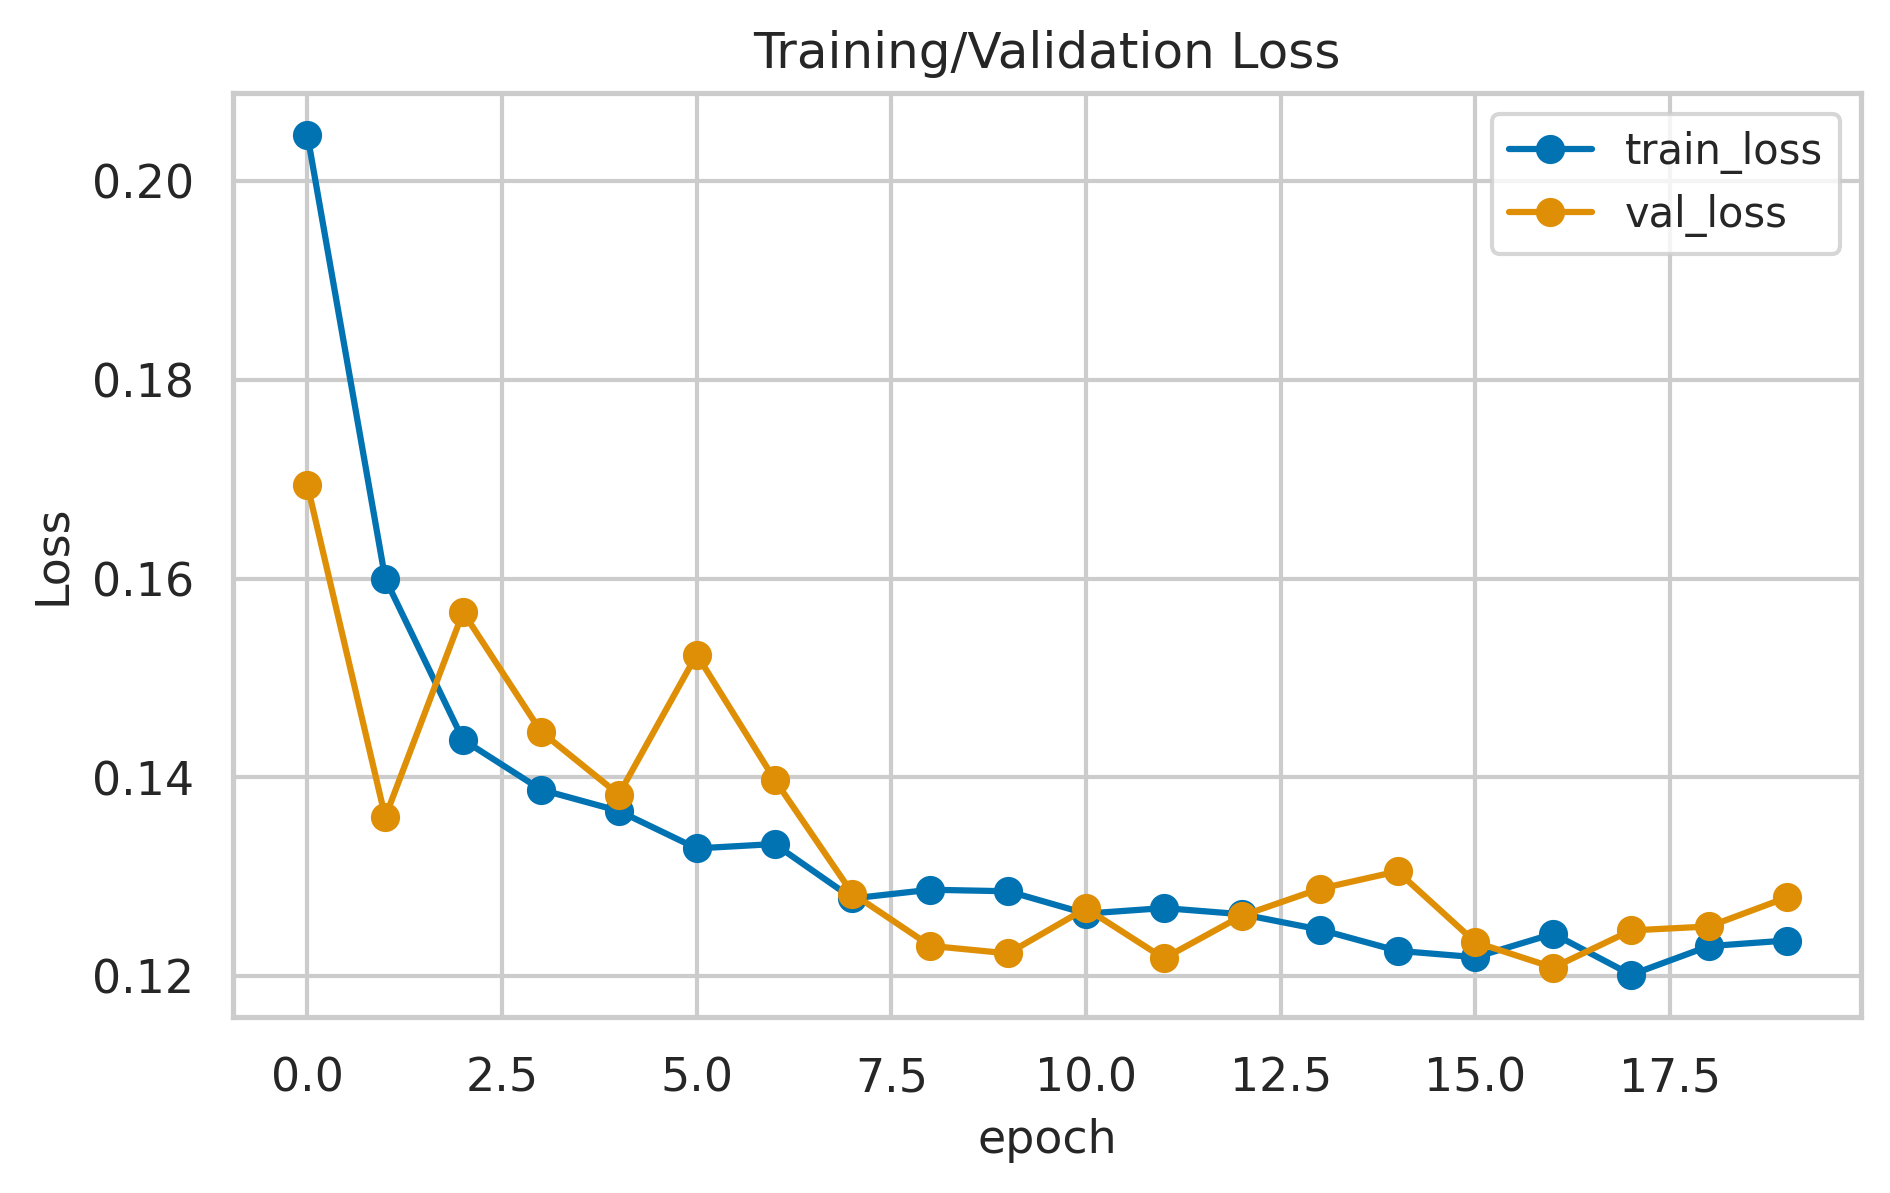

Saved figure to ../training_runs/resampled_20251206-154401_resnet18/plots/train_val_metrics.pdf


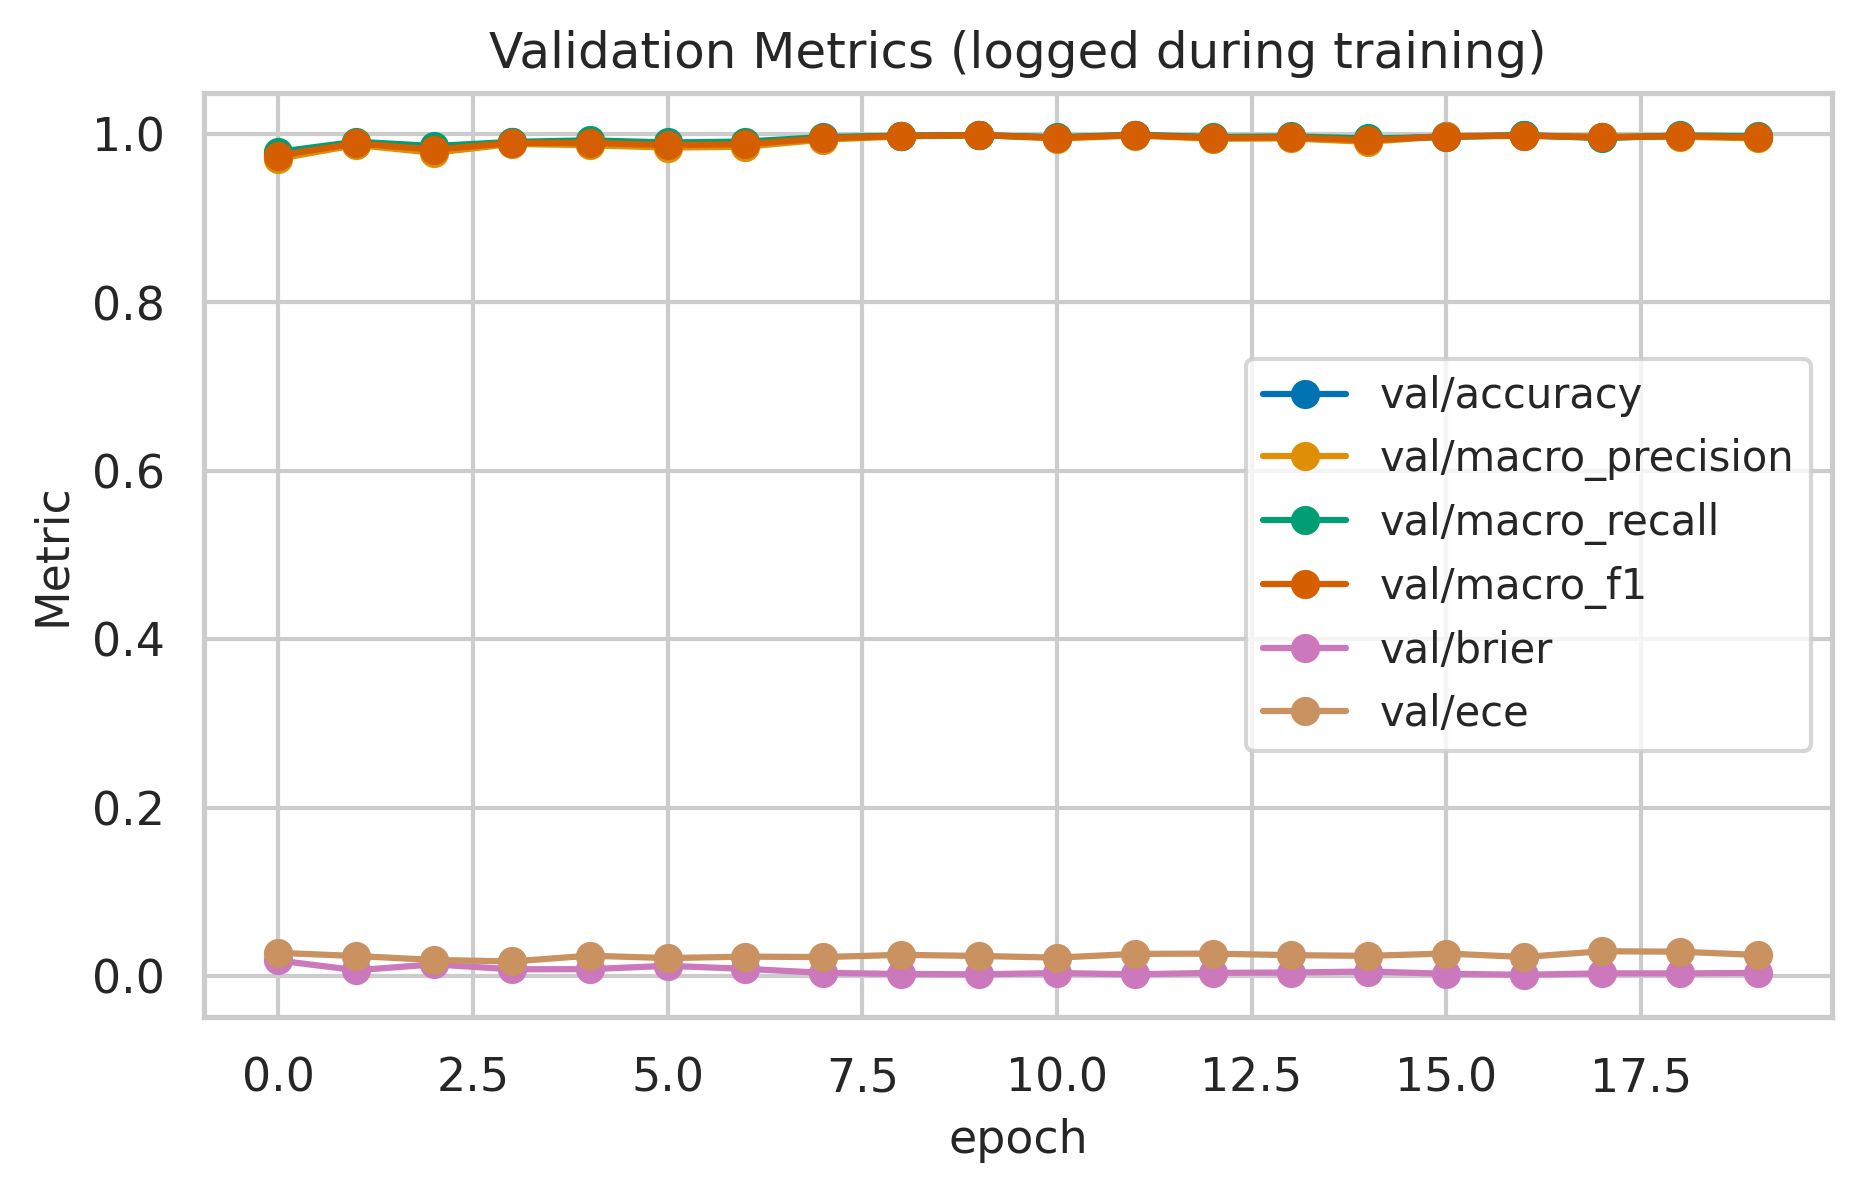

Finished training resnet18 -> ../training_runs/resampled_20251206-154401_resnet18
Best validation macro_f1: 0.9984


In [12]:
# resnet18 configuration + training
resnet18_overrides = {**BASE_OVERRIDES, **{'model_name': 'resnet18', 'batch_size': 64, 'lr': 0.0003, 'dropout': 0.2, 'image_size': 256}}
resnet18_run = run_experiment("resnet18", resnet18_overrides)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /home/tim/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 219MB/s] 


Epoch 1/50:   0%|          | 0/395 [00:00<?, ?it/s]

2025-12-06 15:50:32,078 | INFO | Epoch 000 | train_loss=0.2198 | val_loss=0.1485 | val_f1=0.984


Epoch 2/50:   0%|          | 0/395 [00:00<?, ?it/s]

...

Epoch 19/50:   0%|          | 0/395 [00:00<?, ?it/s]

2025-12-06 15:56:16,824 | INFO | Epoch 018 | train_loss=0.1236 | val_loss=0.1233 | val_f1=0.996


Epoch 20/50:   0%|          | 0/395 [00:00<?, ?it/s]

2025-12-06 15:56:35,473 | INFO | Epoch 019 | train_loss=0.1224 | val_loss=0.1227 | val_f1=0.997
2025-12-06 15:56:35,473 | INFO | Early stopping.


Saved figure to ../training_runs/resampled_20251206-154401_resnet34/plots/train_loss_curves.pdf


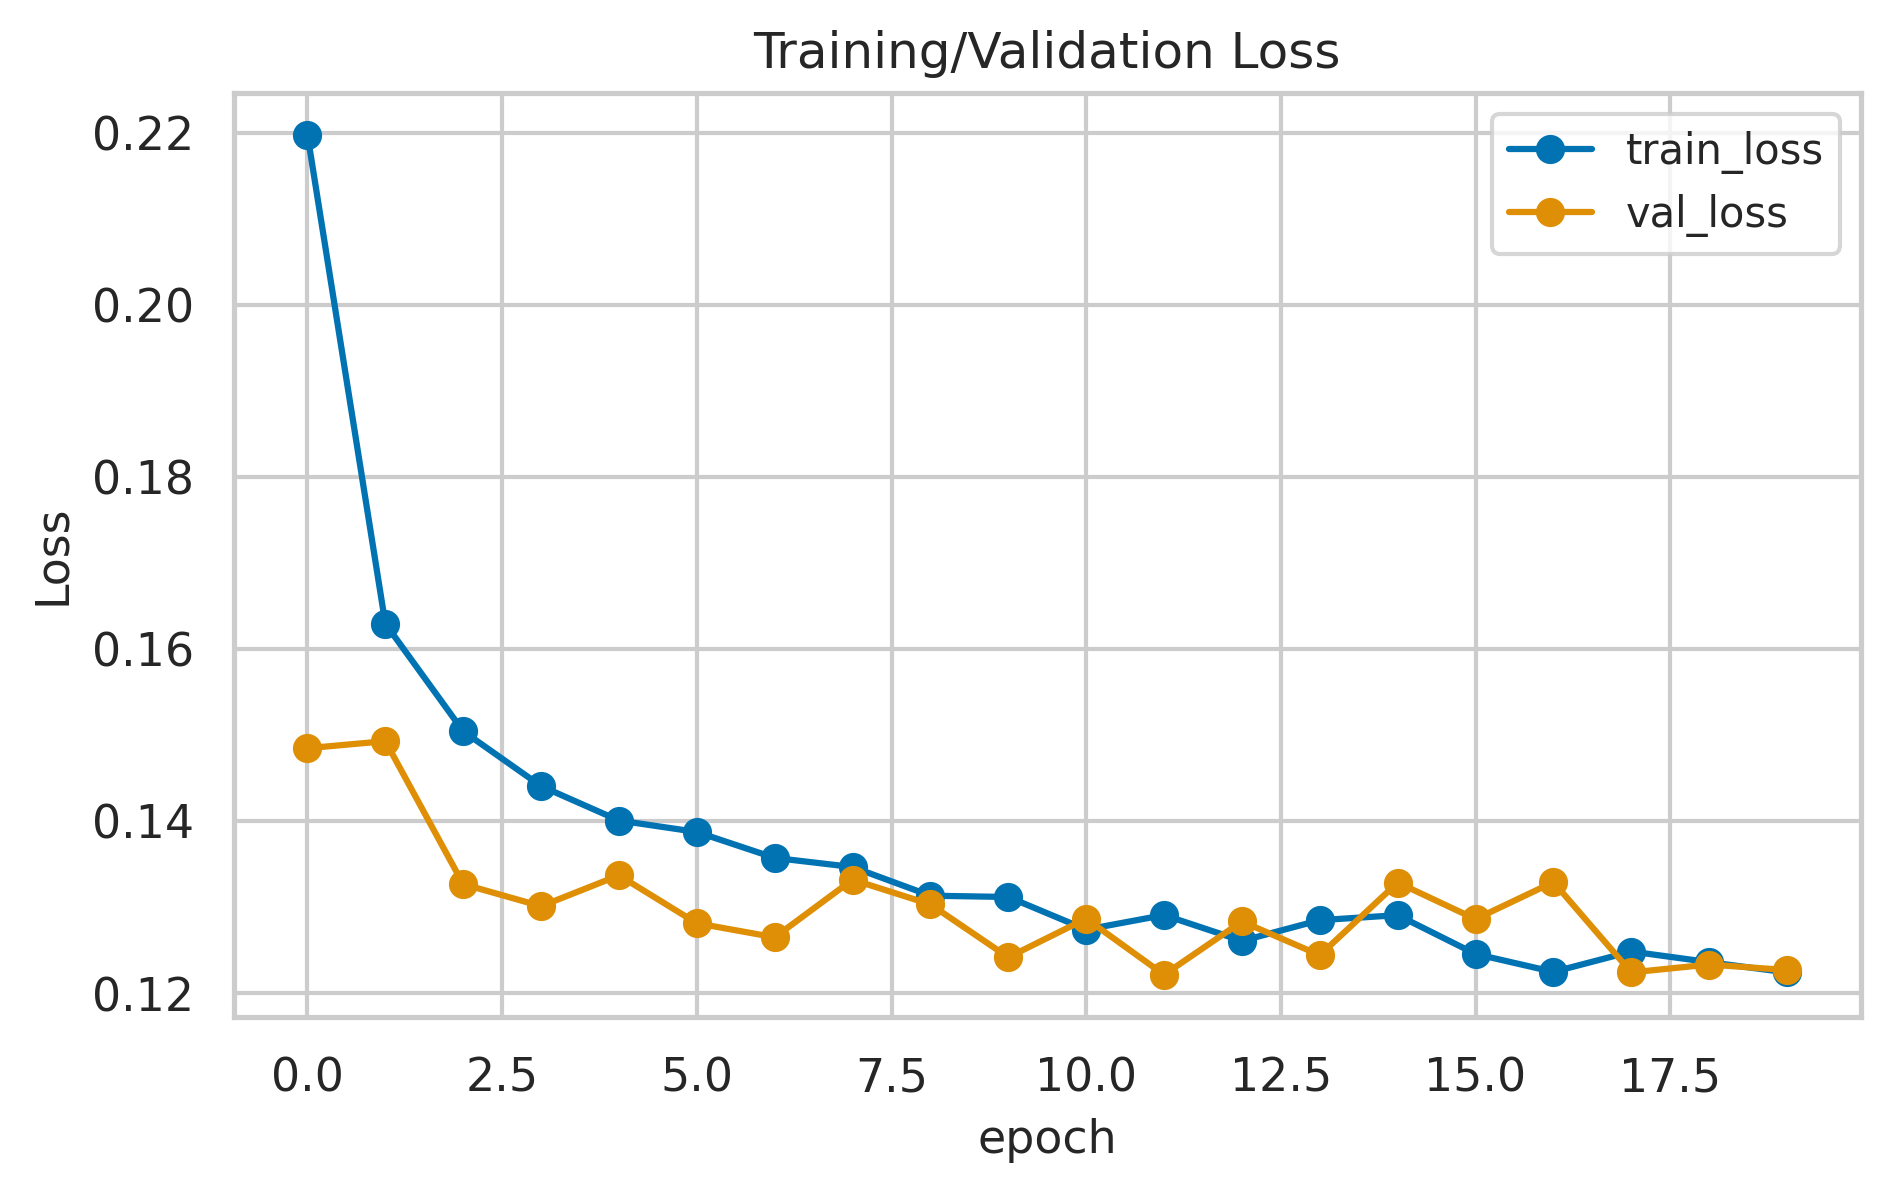

Saved figure to ../training_runs/resampled_20251206-154401_resnet34/plots/train_val_metrics.pdf


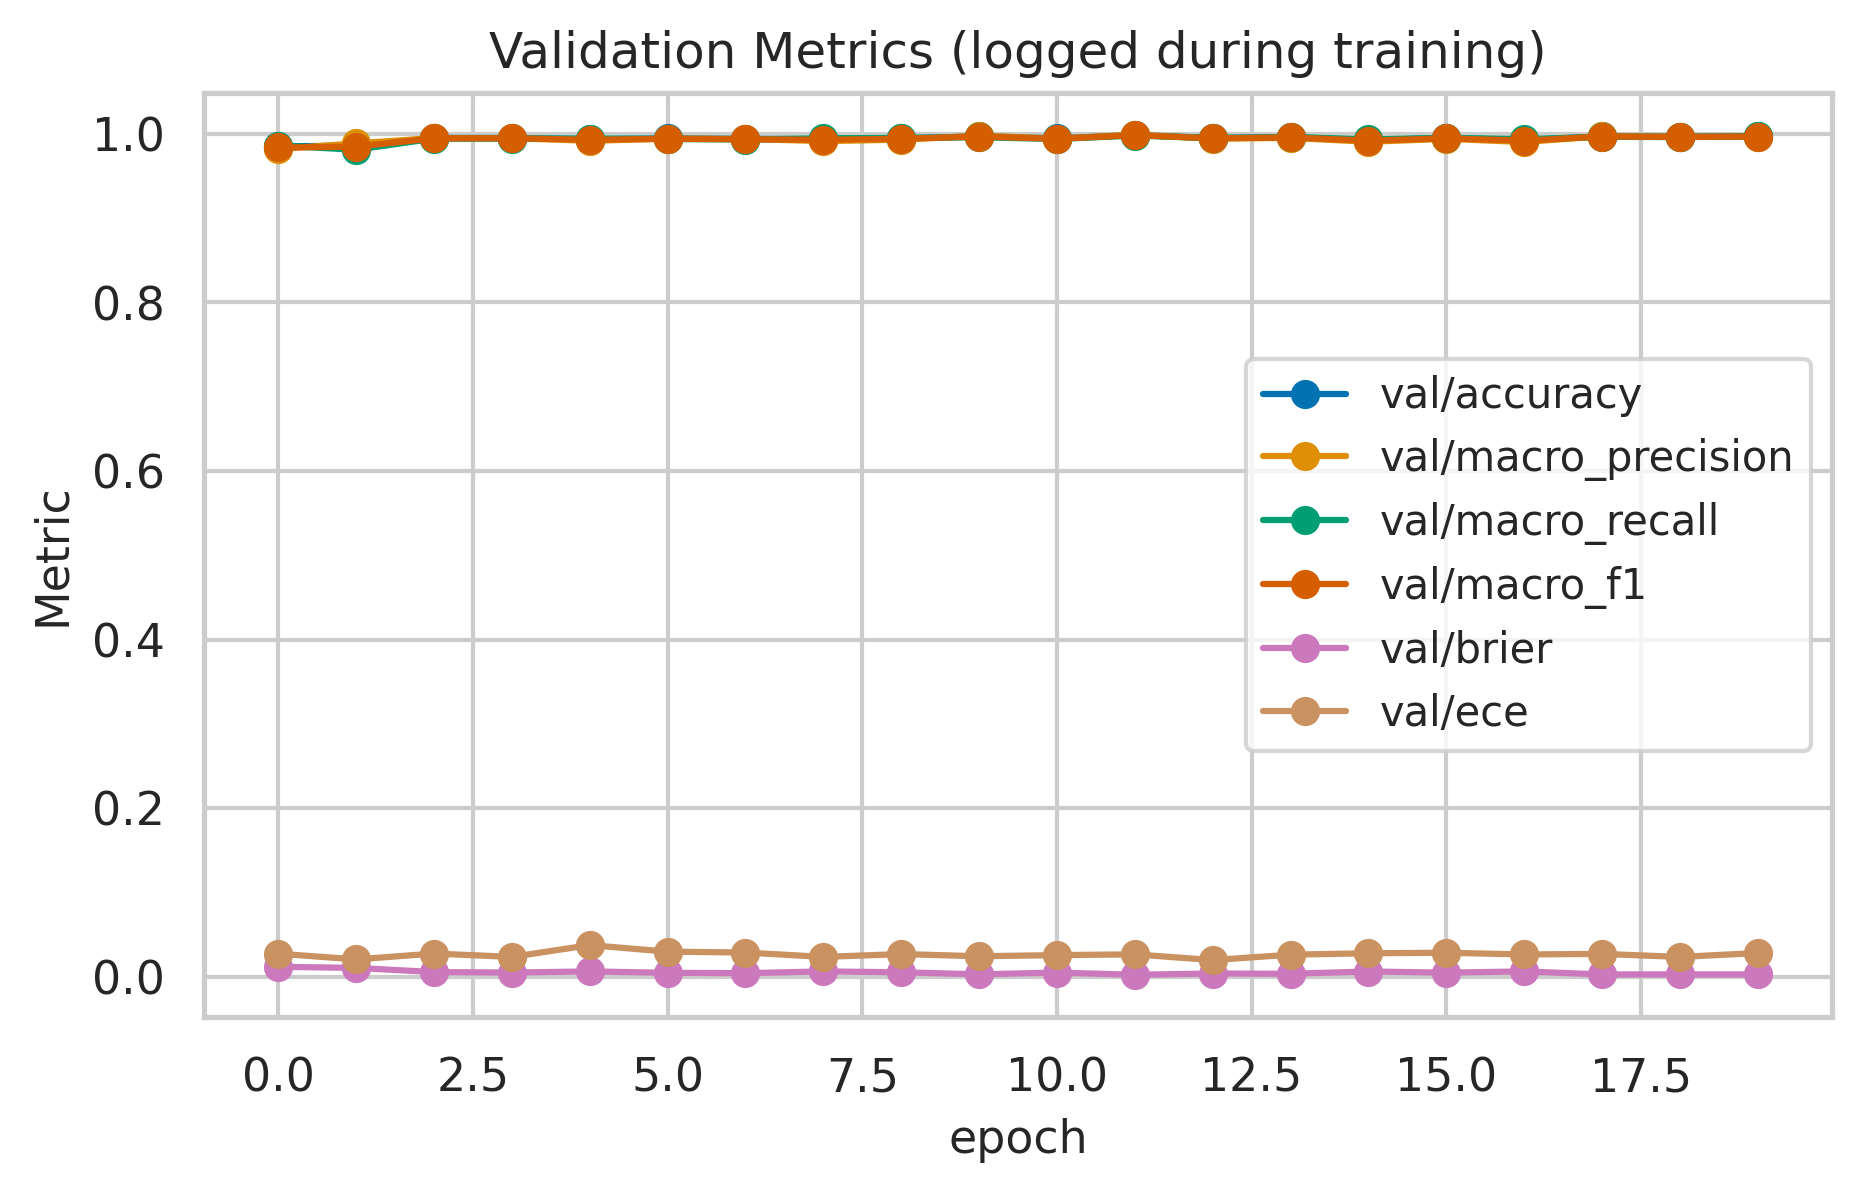

Finished training resnet34 -> ../training_runs/resampled_20251206-154401_resnet34
Best validation macro_f1: 0.9984


In [13]:
# resnet34 configuration + training
resnet34_overrides = {**BASE_OVERRIDES, **{'model_name': 'resnet34', 'batch_size': 48, 'lr': 0.0003, 'dropout': 0.2, 'image_size': 256}}
resnet34_run = run_experiment("resnet34", resnet34_overrides)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/tim/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 241MB/s]


Epoch 1/50:   0%|          | 0/593 [00:00<?, ?it/s]

2025-12-06 15:56:58,180 | INFO | Epoch 000 | train_loss=0.2028 | val_loss=0.1656 | val_f1=0.980


Epoch 2/50:   0%|          | 0/593 [00:00<?, ?it/s]

...

Epoch 33/50:   0%|          | 0/593 [00:00<?, ?it/s]

2025-12-06 16:08:27,912 | INFO | Epoch 032 | train_loss=0.1182 | val_loss=0.1189 | val_f1=0.999


Epoch 34/50:   0%|          | 0/593 [00:00<?, ?it/s]

2025-12-06 16:08:50,780 | INFO | Epoch 033 | train_loss=0.1176 | val_loss=0.1190 | val_f1=0.999
2025-12-06 16:08:50,780 | INFO | Early stopping.


Saved figure to ../training_runs/resampled_20251206-154401_resnet50/plots/train_loss_curves.pdf


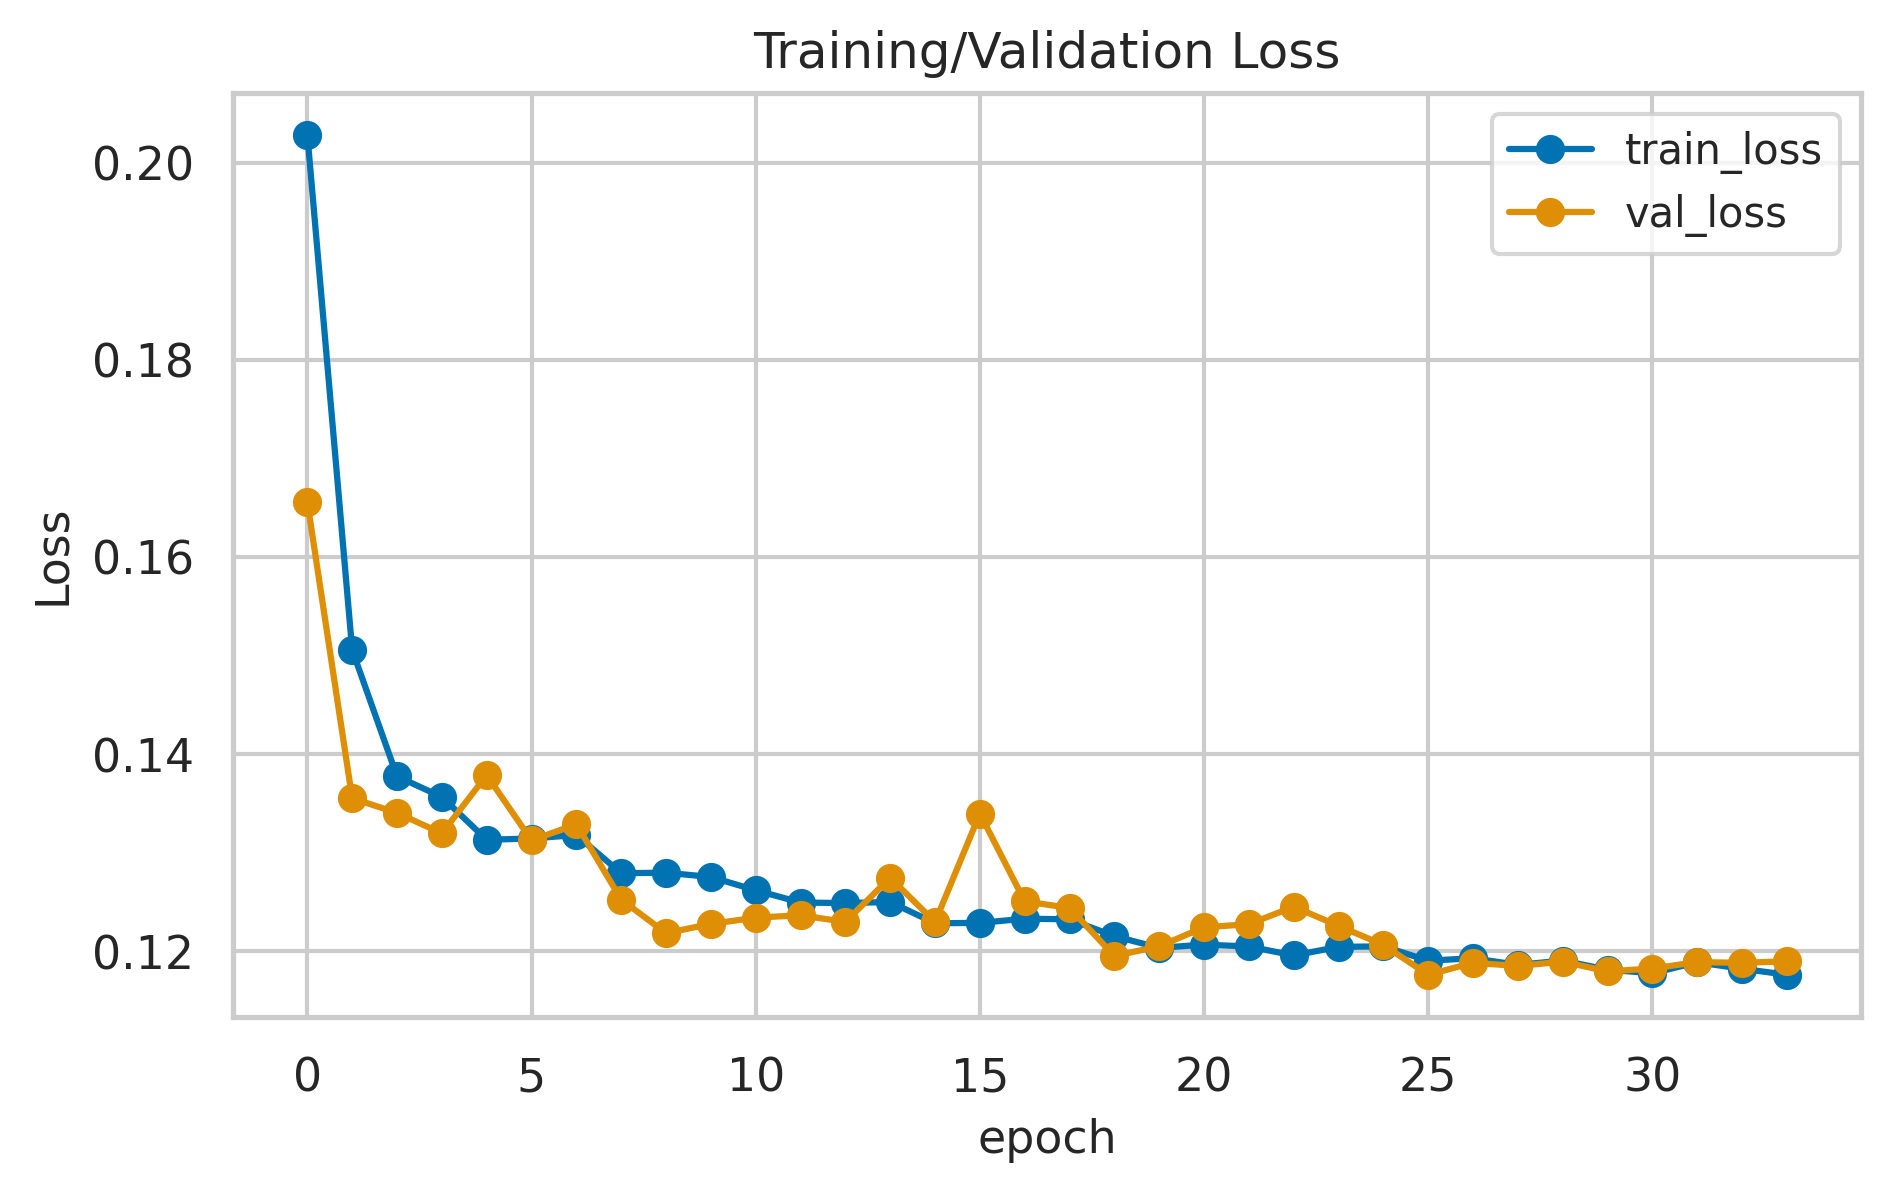

Saved figure to ../training_runs/resampled_20251206-154401_resnet50/plots/train_val_metrics.pdf


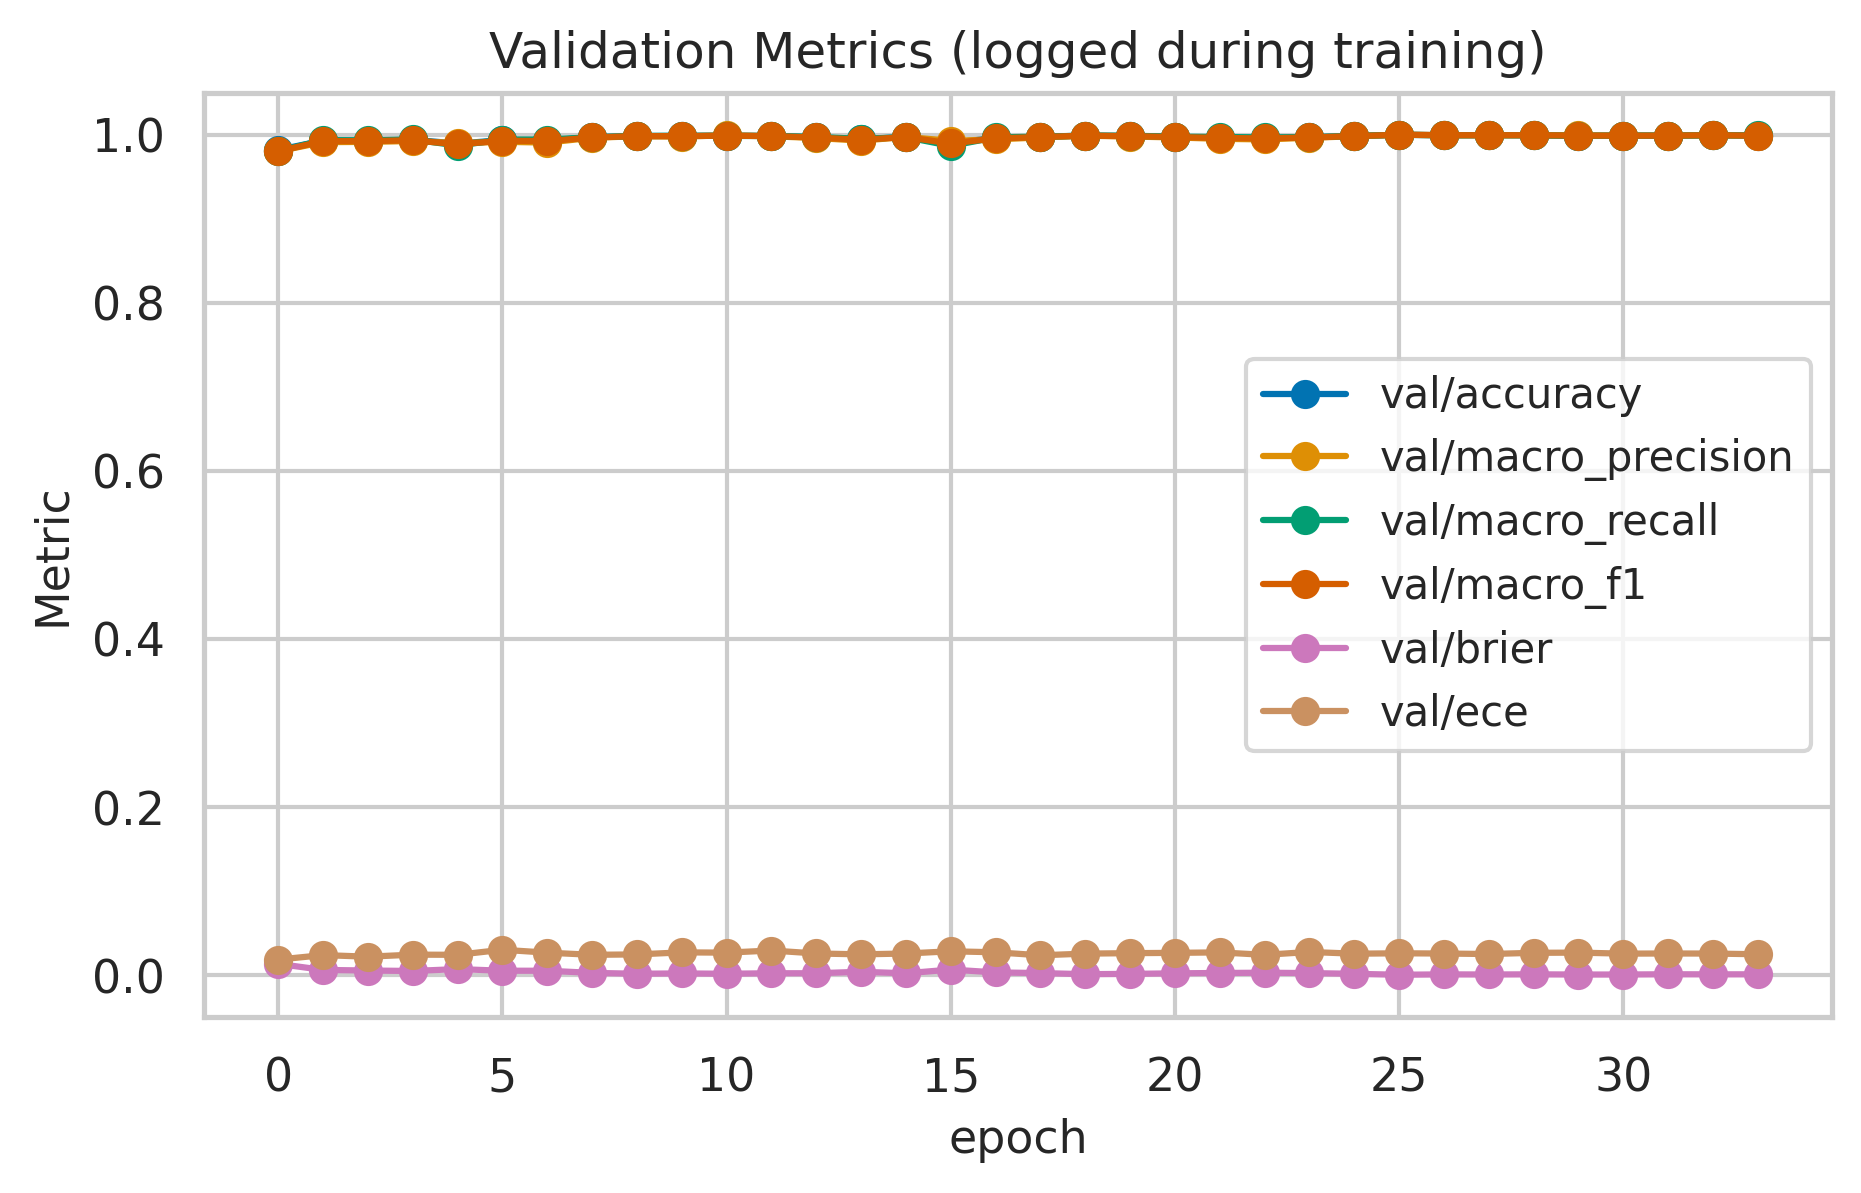

Finished training resnet50 -> ../training_runs/resampled_20251206-154401_resnet50
Best validation macro_f1: 1.0000


In [14]:
# resnet50 configuration + training
resnet50_overrides = {**BASE_OVERRIDES, **{'model_name': 'resnet50', 'batch_size': 32, 'lr': 0.00025, 'dropout': 0.25, 'image_size': 256}}
resnet50_run = run_experiment("resnet50", resnet50_overrides)

Downloading: "https://download.pytorch.org/models/efficientnet_b1-c27df63c.pth" to /home/tim/.cache/torch/hub/checkpoints/efficientnet_b1-c27df63c.pth


100%|██████████| 30.1M/30.1M [00:00<00:00, 232MB/s]


Epoch 1/50:   0%|          | 0/395 [00:00<?, ?it/s]

2025-12-06 16:09:18,185 | INFO | Epoch 000 | train_loss=0.2012 | val_loss=0.1423 | val_f1=0.986


Epoch 2/50:   0%|          | 0/395 [00:00<?, ?it/s]

...

Epoch 11/50:   0%|          | 0/395 [00:00<?, ?it/s]

2025-12-06 16:12:45,713 | INFO | Epoch 010 | train_loss=0.1203 | val_loss=0.1246 | val_f1=0.996


Epoch 12/50:   0%|          | 0/395 [00:00<?, ?it/s]

2025-12-06 16:13:05,903 | INFO | Epoch 011 | train_loss=0.1211 | val_loss=0.1249 | val_f1=0.997
2025-12-06 16:13:05,904 | INFO | Early stopping.


Saved figure to ../training_runs/resampled_20251206-154401_efficientnet_b1/plots/train_loss_curves.pdf


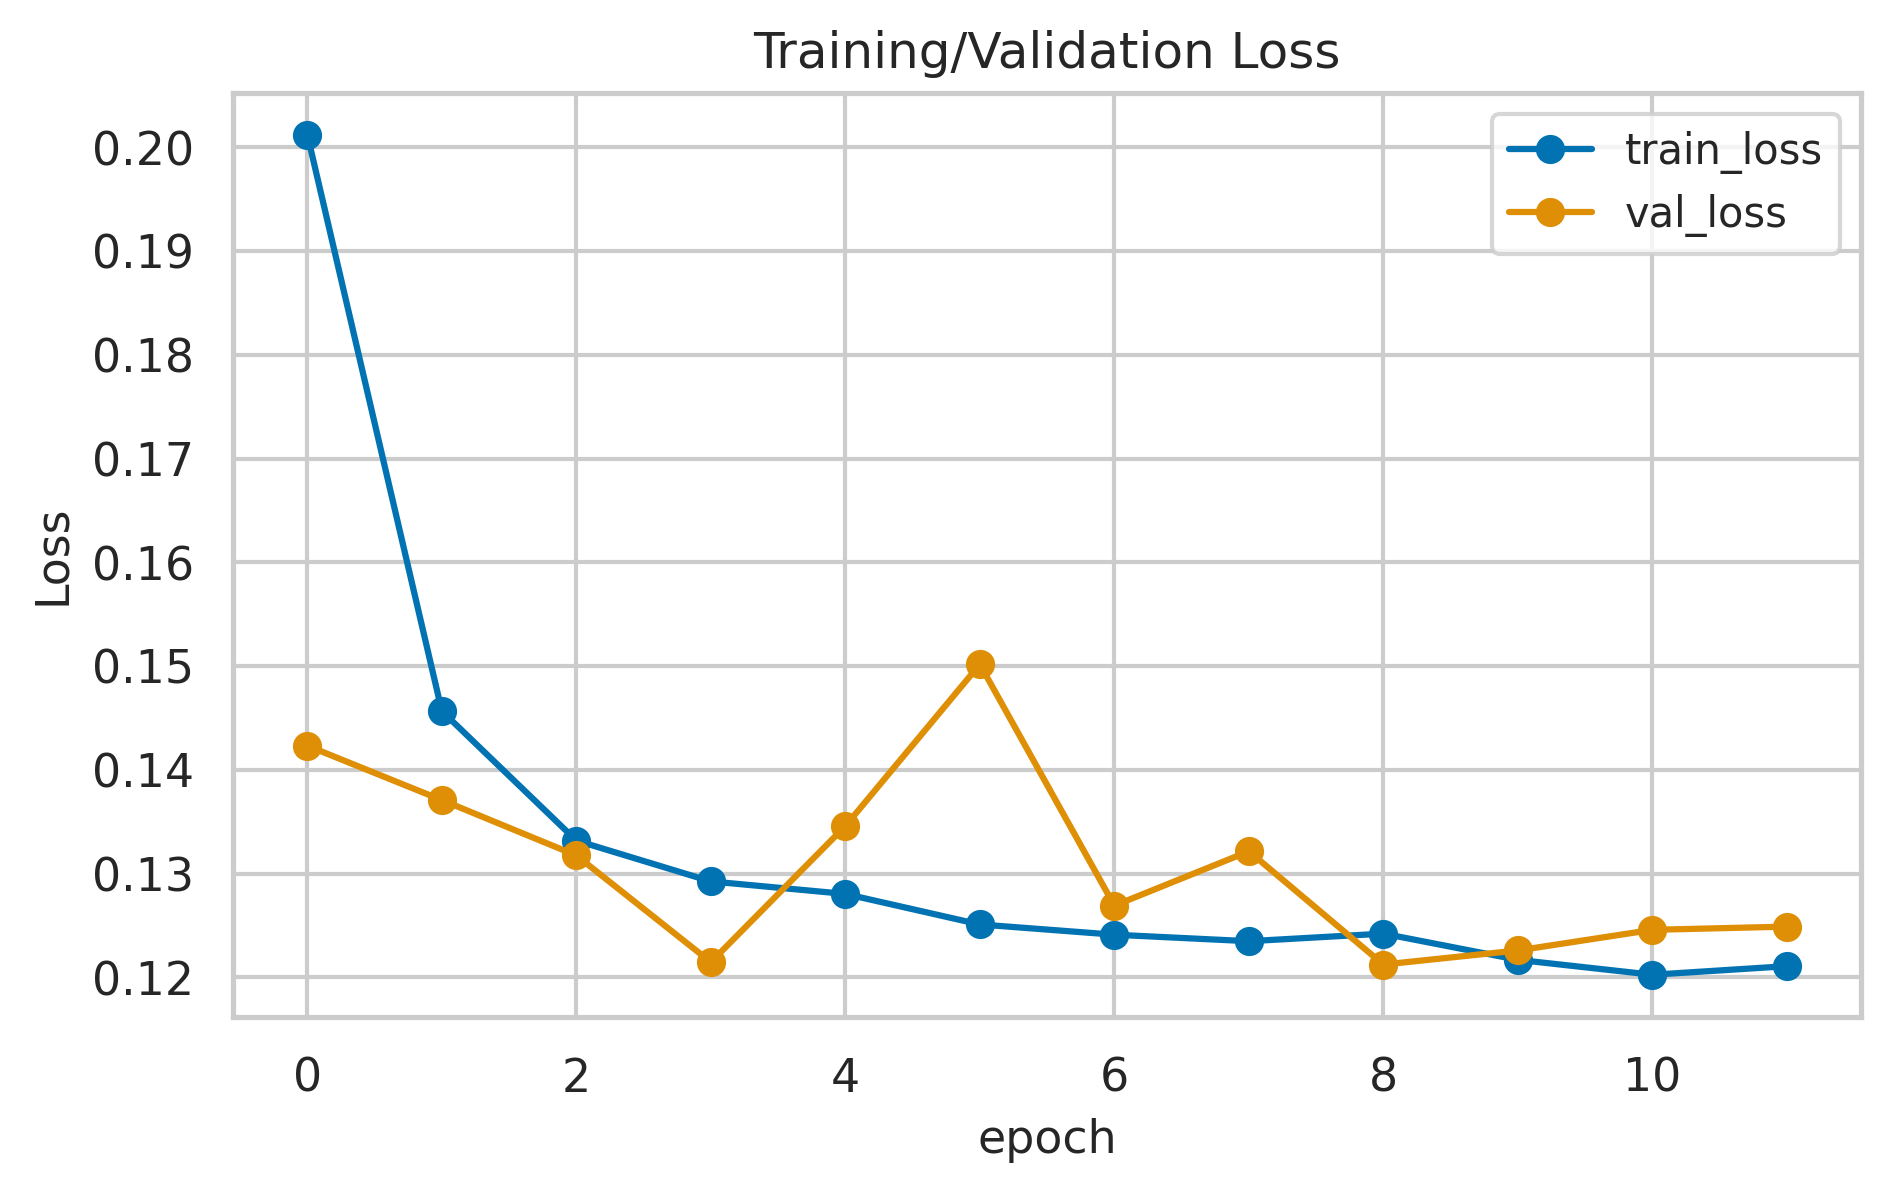

Saved figure to ../training_runs/resampled_20251206-154401_efficientnet_b1/plots/train_val_metrics.pdf


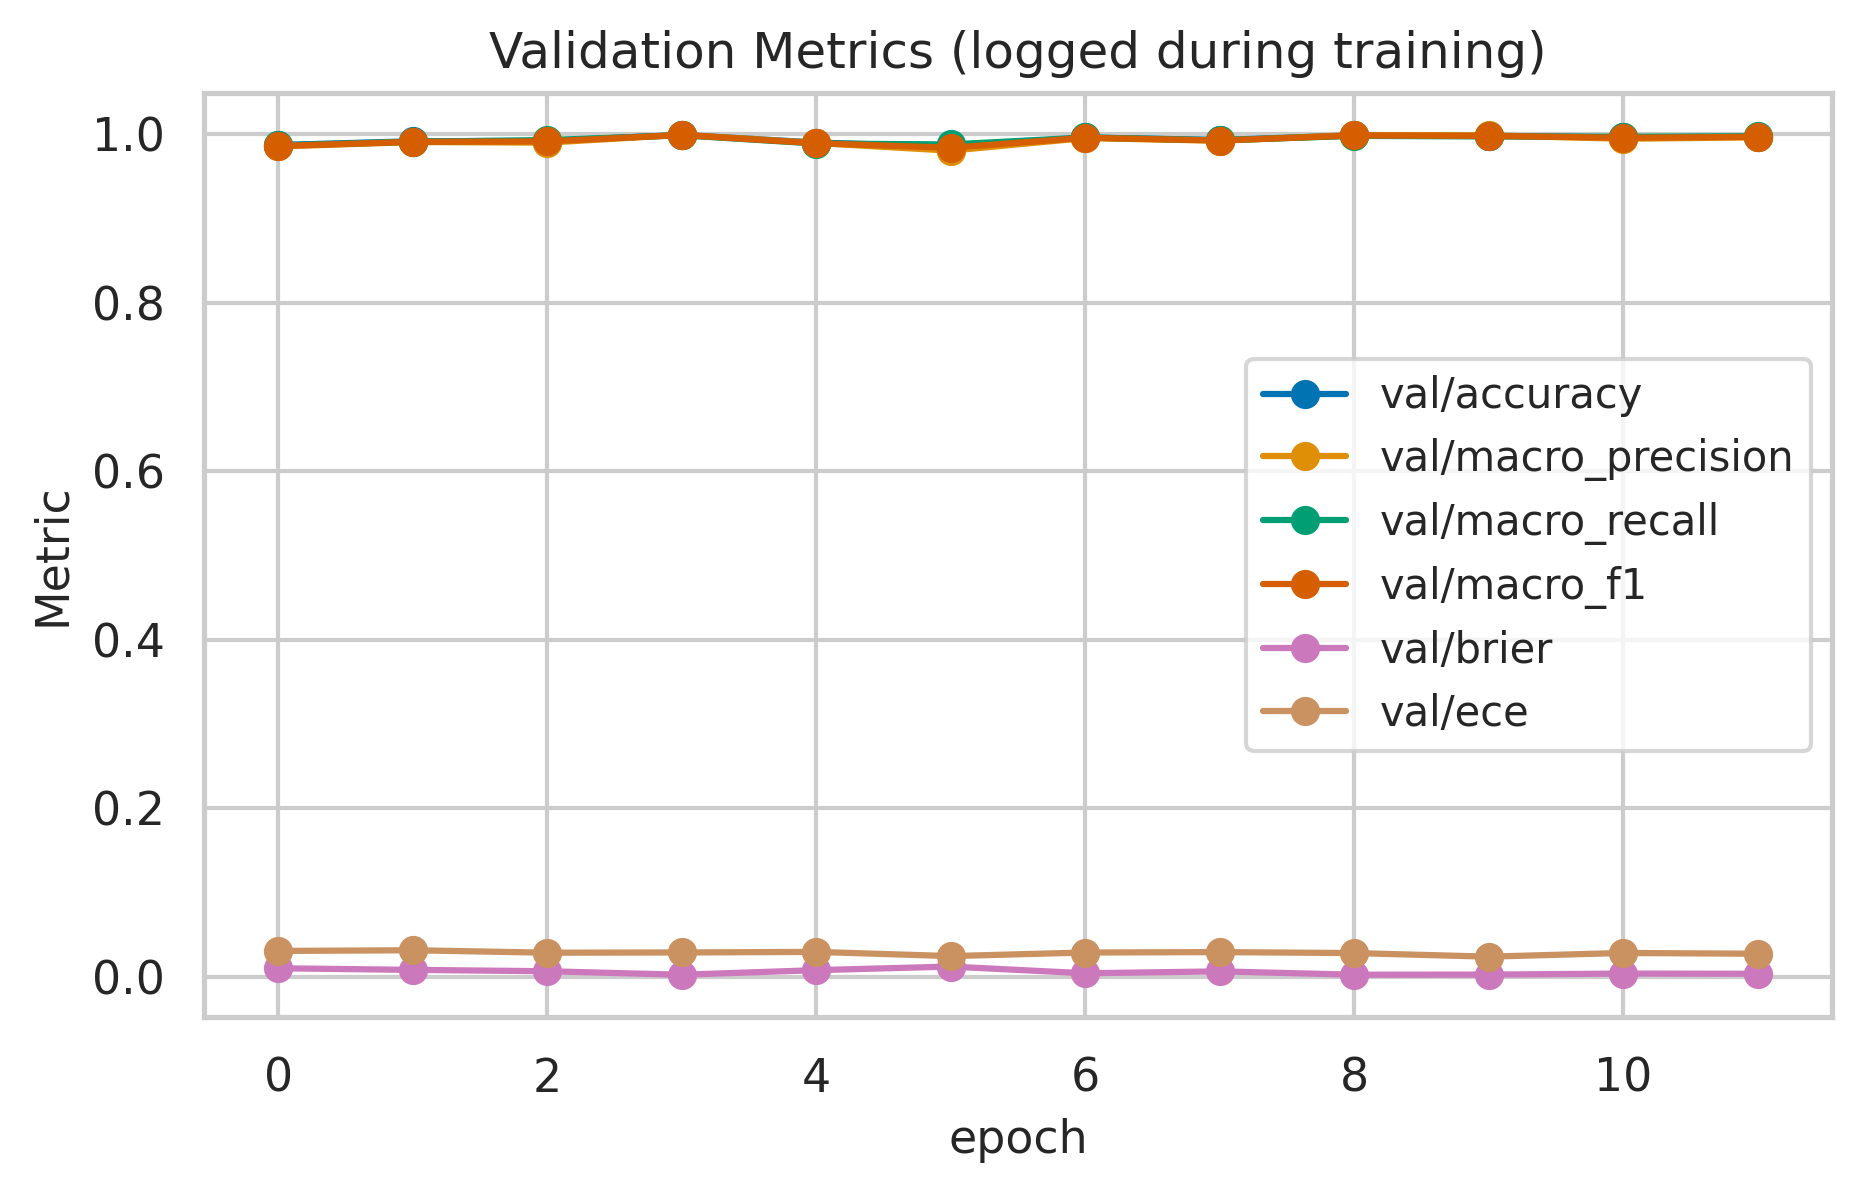

Finished training efficientnet_b1 -> ../training_runs/resampled_20251206-154401_efficientnet_b1
Best validation macro_f1: 0.9989


In [15]:
# efficientnet_b1 configuration + training
efficientnet_b1_overrides = {**BASE_OVERRIDES, **{'model_name': 'efficientnet_b1', 'batch_size': 48, 'lr': 0.0003, 'dropout': 0.3, 'image_size': 240}}
efficientnet_b1_run = run_experiment("efficientnet_b1", efficientnet_b1_overrides)

Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /home/tim/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 294MB/s]


Epoch 1/50:   0%|          | 0/527 [00:00<?, ?it/s]

2025-12-06 16:13:37,298 | INFO | Epoch 000 | train_loss=0.1888 | val_loss=0.1398 | val_f1=0.990


Epoch 2/50:   0%|          | 0/527 [00:00<?, ?it/s]

...

Epoch 20/50:   0%|          | 0/527 [00:00<?, ?it/s]

2025-12-06 16:21:45,822 | INFO | Epoch 019 | train_loss=0.1188 | val_loss=0.1188 | val_f1=0.999


Epoch 21/50:   0%|          | 0/527 [00:00<?, ?it/s]

2025-12-06 16:22:11,772 | INFO | Epoch 020 | train_loss=0.1194 | val_loss=0.1188 | val_f1=0.999
2025-12-06 16:22:11,773 | INFO | Early stopping.


Saved figure to ../training_runs/resampled_20251206-154401_efficientnet_b2/plots/train_loss_curves.pdf


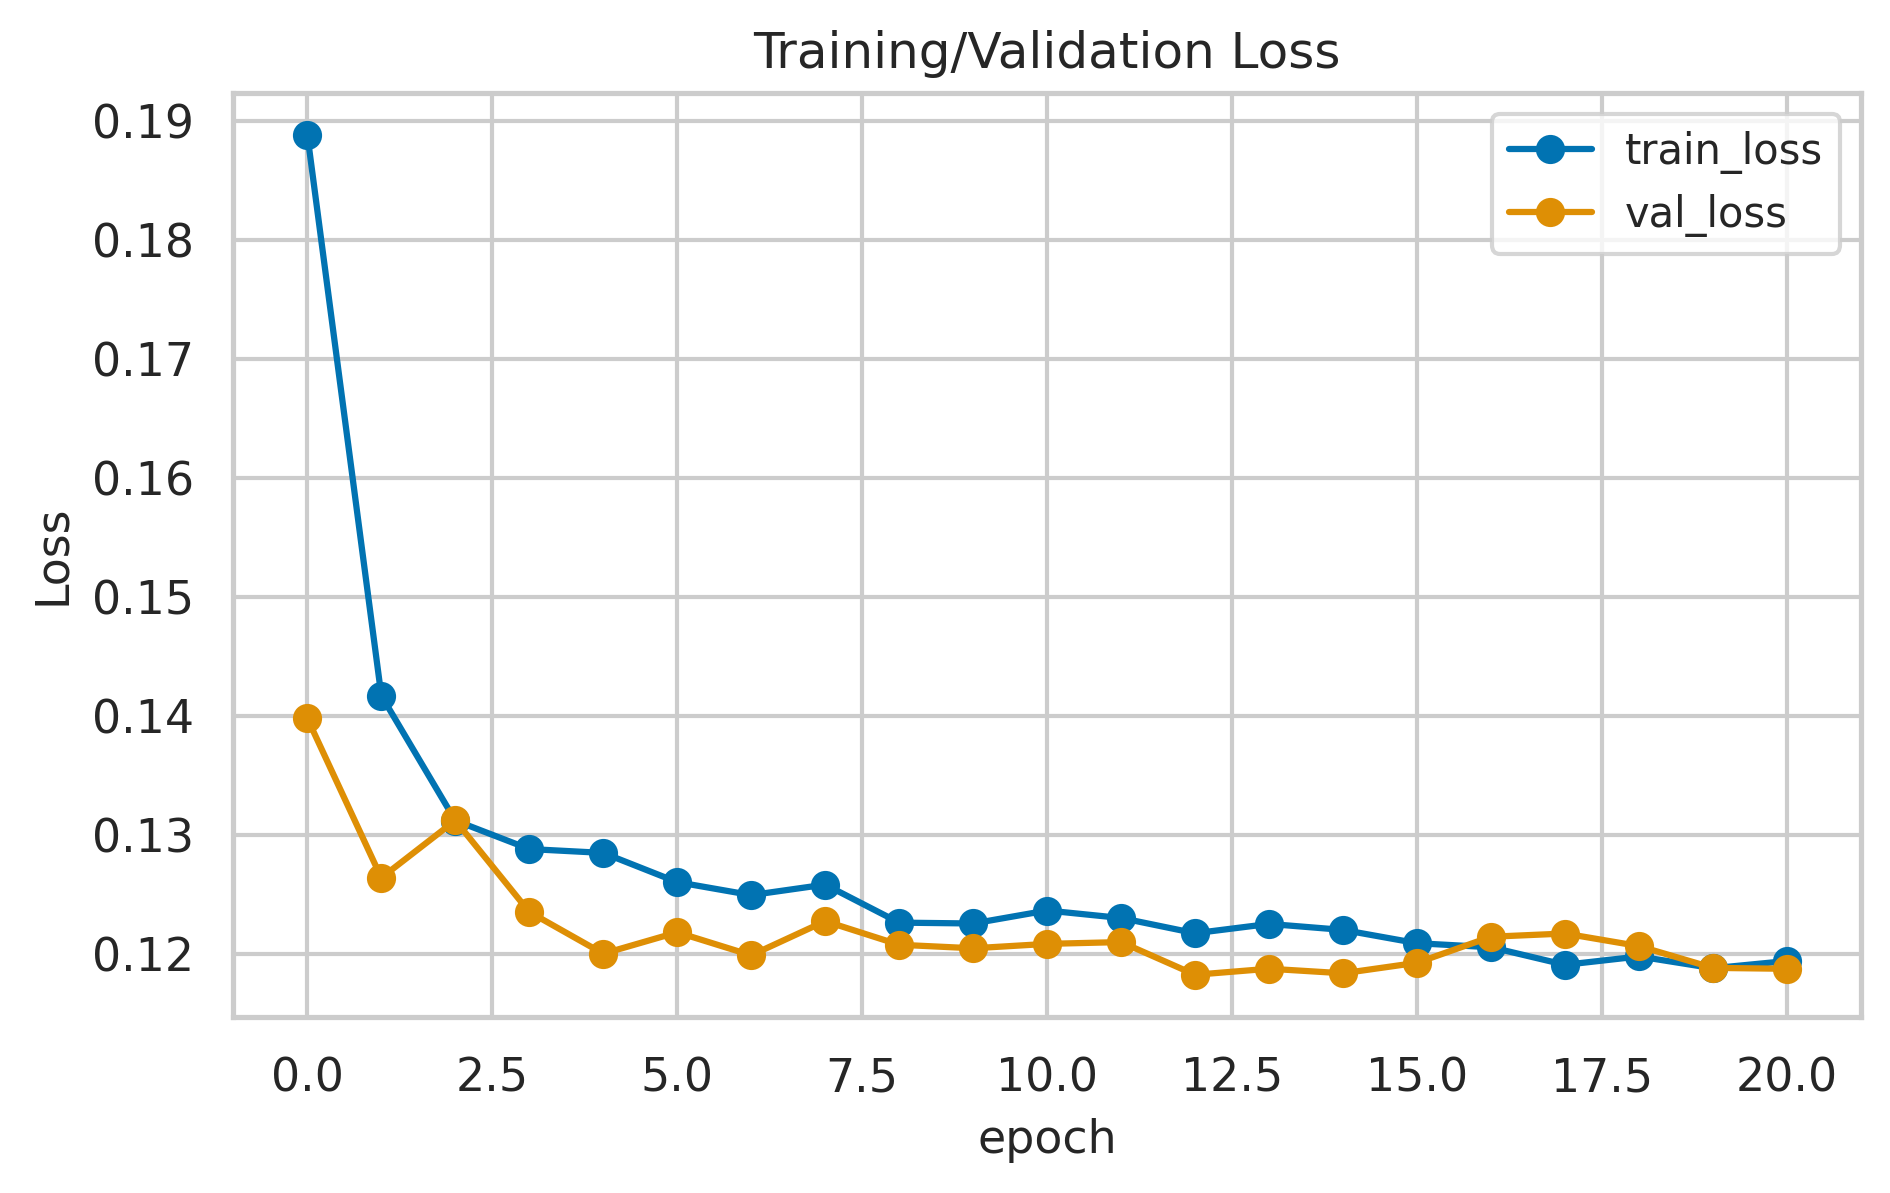

Saved figure to ../training_runs/resampled_20251206-154401_efficientnet_b2/plots/train_val_metrics.pdf


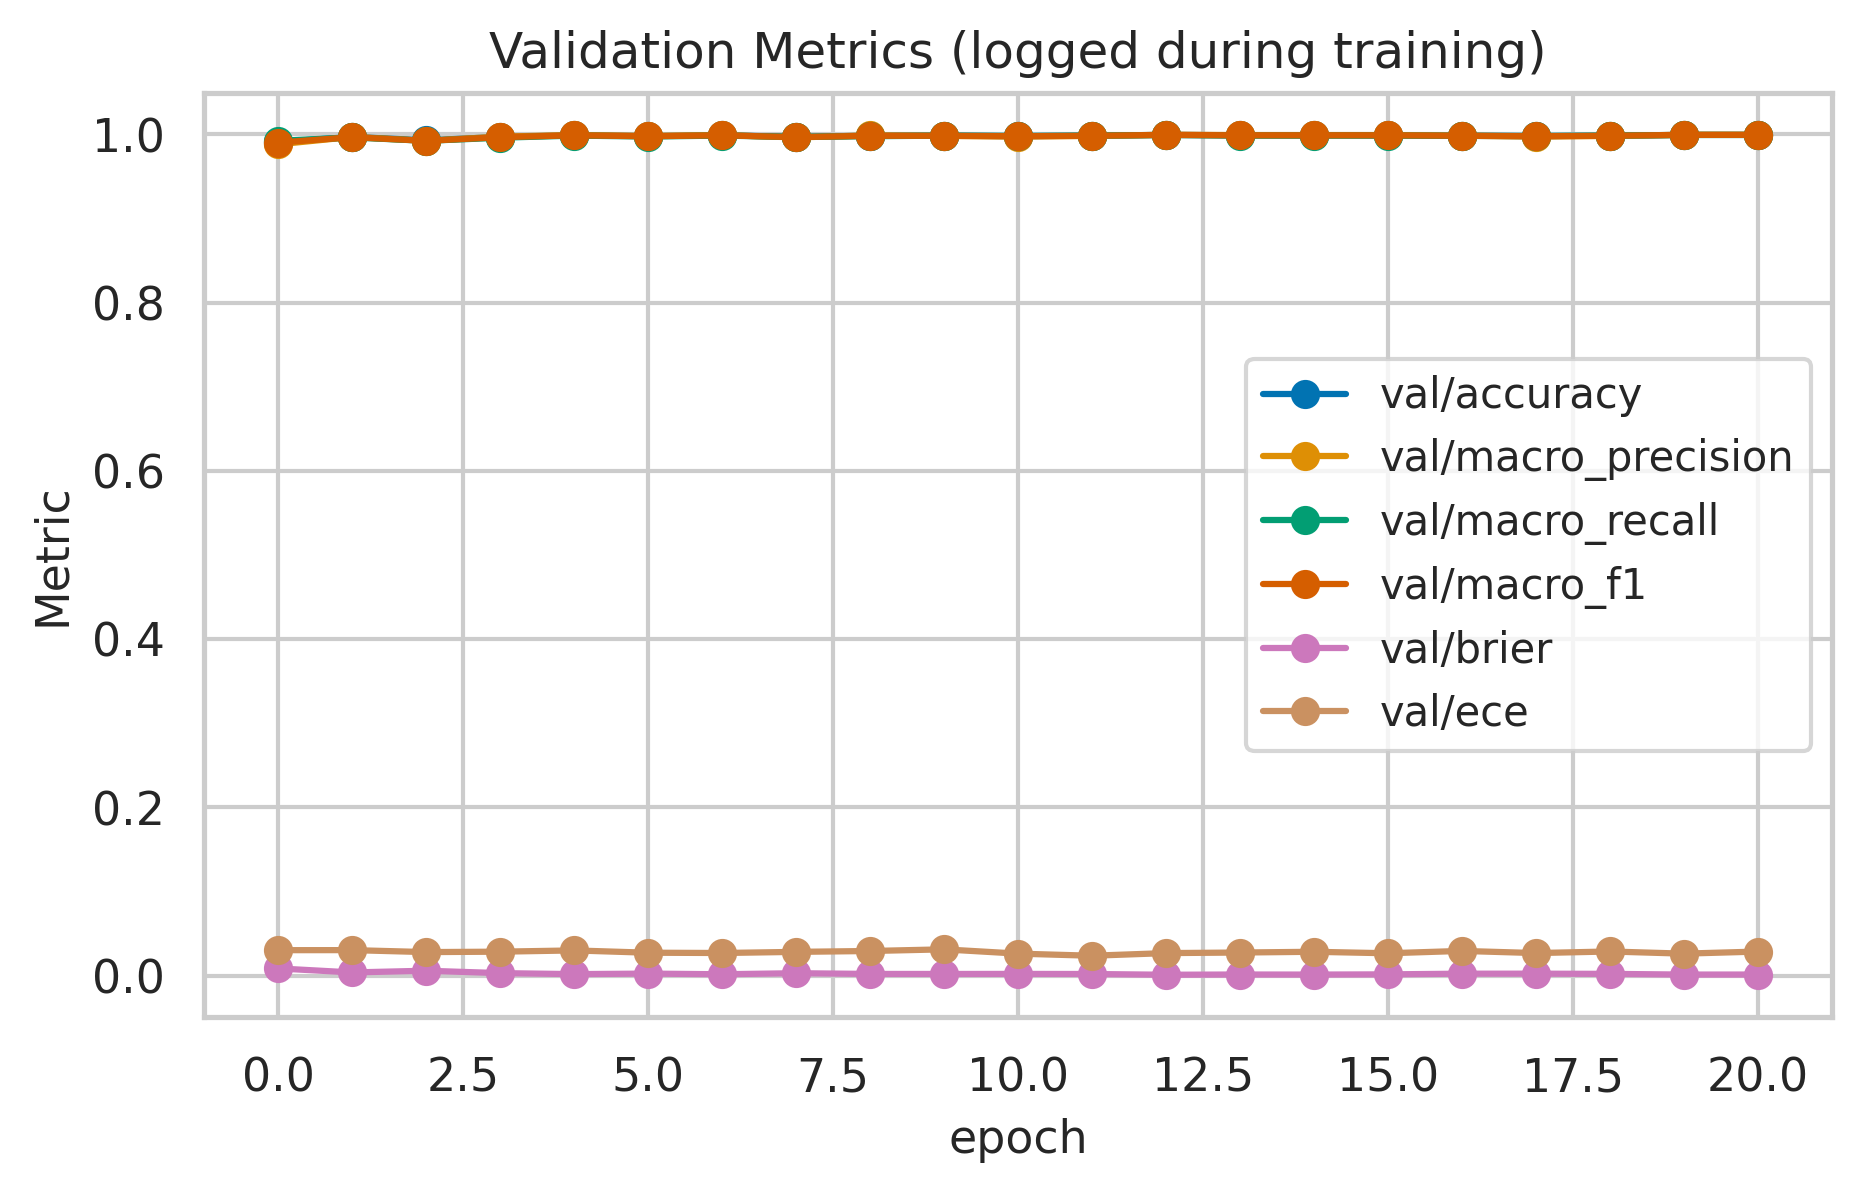

Finished training efficientnet_b2 -> ../training_runs/resampled_20251206-154401_efficientnet_b2
Best validation macro_f1: 0.9995


In [16]:
# efficientnet_b2 configuration + training
efficientnet_b2_overrides = {**BASE_OVERRIDES, **{'model_name': 'efficientnet_b2', 'batch_size': 36, 'lr': 0.0003, 'dropout': 0.3, 'image_size': 260}}
efficientnet_b2_run = run_experiment("efficientnet_b2", efficientnet_b2_overrides)

In [17]:
# convnext_tiny configuration + training
convnext_tiny_overrides = {**BASE_OVERRIDES, **{'model_name': 'convnext_tiny', 'batch_size': 48, 'lr': 0.0005, 'weight_decay': 5e-05, 'image_size': 256}}
convnext_tiny_run = run_experiment("convnext_tiny", convnext_tiny_overrides)

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /home/tim/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 162MB/s] 


Epoch 1/50:   0%|          | 0/395 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# convnext_small configuration + training
convnext_small_overrides = {**BASE_OVERRIDES, **{'model_name': 'convnext_small', 'batch_size': 32, 'lr': 0.0005, 'weight_decay': 5e-05, 'image_size': 256}}
convnext_small_run = run_experiment("convnext_small", convnext_small_overrides)

In [ ]:
# custom_cnn configuration + training
custom_cnn_overrides = {**BASE_OVERRIDES, **{'model_name': 'custom_cnn', 'batch_size': 96, 'lr': 0.001, 'dropout': 0.3, 'pretrained': False, 'image_size': 256}}
custom_cnn_run = run_experiment("custom_cnn", custom_cnn_overrides)